# E-Scooter — Modèles de choix discret (Biogeme)
## Variable dépendante : accélérer (1) vs décélérer/maintenir (0)

| Etape | Contenu |
|-------|---------|
| 1 | Imports |
| 2 | Chargement |
| 3 | Reduction 1 Hz |
| 4 | Variable dependante delta_speed |
| 5 | Standardisation + effets fixes |
| 6 | Helper Biogeme |
| 7 | M0 : null model |
| 8 | M1 : pietons + distance |
| 9 | M2 : + largeur route |
| 10 | M3 : complet + effets fixes |
| 11 | Comparaison modeles |
| 12 | Forest plot coefficients |
| 13 | Effets marginaux |
| 14 | Courbes probabilite predite |
| 15 | Synthese |


## 1 · Imports & configuration

In [30]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import biogeme.biogeme as bio
import biogeme.database as db
import biogeme.expressions as Variables
import biogeme.expressions as ex
from biogeme.expressions import Beta, Variable, bioDraws, MonteCarlo, exp, log, Elem, bioNormalCdf
import biogeme.models as models
import biogeme.results_processing as rp
from biogeme.parameters import Parameters

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

DATASET_PATH = '/Volumes/My Passport/NEWMOB/clean_dataset.csv'  # meme dossier que ce notebook
FPS          = 30                   # frames par seconde
COLOR_ACC    = '#2E86AB'
COLOR_DEC    = '#E84855'


## 2 · Chargement du dataset

In [31]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Dataset brut : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes')
print(f'Trajets      : {df_raw["source"].nunique()}')
display(df_raw.head(4))
print()
print('Valeurs manquantes :')
display(df_raw.isna().sum().to_frame('n_missing'))


Dataset brut : 423,410 lignes x 60 colonnes
Trajets      : 25


,source,frame,speed_kmh,gyrz_deg_s,n_vru_total,n_pedestrians,n_cyclists,n_escooters,prop_vru_pedestrian,prop_vru_cyclist,...,pct_stationary,pct_gait_standing,pct_gait_walking,pct_gait_running,pct_gait_unknown,pct_age_child,pct_age_adult,pct_age_elderly,pct_age_unknown,pct_unknown_interaction
0,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0



Valeurs manquantes :


,n_missing
source,0
frame,0
speed_kmh,8691
gyrz_deg_s,8691
n_vru_total,0
n_pedestrians,0
n_cyclists,0
n_escooters,0
prop_vru_pedestrian,0
prop_vru_cyclist,0


## 3 · Reduction a 1 Hz

Le dataset est echantillonne a 30 FPS. On regroupe par **seconde** (`second = frame // 30`) :

| Variable | Agregation | Justification |
|----------|-----------|---------------|
| `speed_kmh` | `mean` | vitesse representative |
| `n_pedestrians` | `max` | situation la plus contraignante |
| `distance_smooth_m` | `min` | distance la plus proche |
| `road_width_perp_m` | `mean` | caracteristique stable |


In [32]:
df_raw['second'] = df_raw['frame'] // FPS

df_1hz = (
    df_raw
    .groupby(['source', 'second'])
    .agg(
        speed_kmh         = ('speed_kmh',          'mean'),
        n_pedestrians     = ('n_pedestrians',       'max'),
       # distance_smooth_m = ('distance_smooth_m',   'min'),
        road_width_perp_m = ('road_width_perp_m',   'mean'),
        # ── Variables temporelles (constantes par trajet → first) ──────────
        hour              = ('hour',                'first'),
        day_of_week       = ('day_of_week',         'first'),
        day_name          = ('day_name',            'first'),
        is_weekend        = ('is_weekend',          'first'),
        time_of_day       = ('time_of_day',         'first'),
        month             = ('month',               'first'),
        season            = ('season',              'first'),
        genre             = ('genre',               'first'),
        age               = ('age',                 'first'),
        experience        = ('experience',          'first'),
        distance_km      = ('distance_km',        'first'),
        prop_vru_pedestrian = ('prop_vru_pedestrian', 'first'),
        prop_vru_cyclist   = ('prop_vru_cyclist',   'first'),
        prop_interaction_same_direction = ('prop_interaction_same_direction', 'max'),
        prop_interaction_opposite_direction = ('prop_interaction_opposite_direction', 'max'),
        prop_interaction_crossing = ('prop_interaction_crossing', 'max'),
        prop_interaction_stationary = ('prop_interaction_stationary', 'max'),
    )
    .reset_index()
    .sort_values(['source', 'second'])
    .reset_index(drop=True)
)

print(f'Après réduction 1 Hz : {len(df_1hz):,} secondes — {df_1hz["source"].nunique()} trajets')
display(df_1hz.describe().round(2))

Après réduction 1 Hz : 1,276 secondes — 25 trajets


,second,speed_kmh,n_pedestrians,road_width_perp_m,hour,day_of_week,month,age,distance_km,prop_vru_pedestrian,prop_vru_cyclist,prop_interaction_same_direction,prop_interaction_opposite_direction,prop_interaction_crossing,prop_interaction_stationary
count,1276.00,1241.00,1276.00,1205.00,1276.00,1276.00,1276.00,1201.00,1201.00,1276.00,1276.00,1276.00,1276.00,1276.00,1276.00
mean,52.41,14.86,3.44,16.92,10.66,3.14,6.84,38.25,151.33,0.89,0.11,0.46,0.45,0.15,0.11
std,45.59,7.52,2.81,13.74,3.56,1.43,2.36,12.66,87.05,0.29,0.29,0.41,0.40,0.30,0.24
min,0.00,2.02,0.00,0.04,5.00,0.00,4.00,21.00,10.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,16.00,9.29,1.00,8.35,6.00,2.00,5.00,29.00,55.69,1.00,0.00,0.00,0.00,0.00,0.00
50%,39.00,12.14,3.00,11.16,10.00,3.00,6.00,31.00,142.27,1.00,0.00,0.50,0.50,0.00,0.00
75%,77.00,20.71,5.00,22.65,13.00,4.00,10.00,55.00,239.34,1.00,0.00,1.00,0.83,0.00,0.00
max,202.00,33.85,15.00,102.76,20.00,6.00,10.00,55.00,323.21,1.00,1.00,1.00,1.00,1.00,1.00


## 4 · Variable dependante : acceleration/deceleration

**Definition :** `delta_speed = speed_kmh(t+1) - speed_kmh(t)` calcule par trajet.

- `delta_speed > 0`  ->  **accelerer** (choice = 1)
- `delta_speed <= 0` ->  **decelerer / maintenir** (choice = 0)

La derniere seconde de chaque trajet est supprimee (pas de t+1).


Observations totales : 1,174
  Accelerer (1) : 580  (49.4 %)
  Decelerer (0) : 594  (50.6 %)


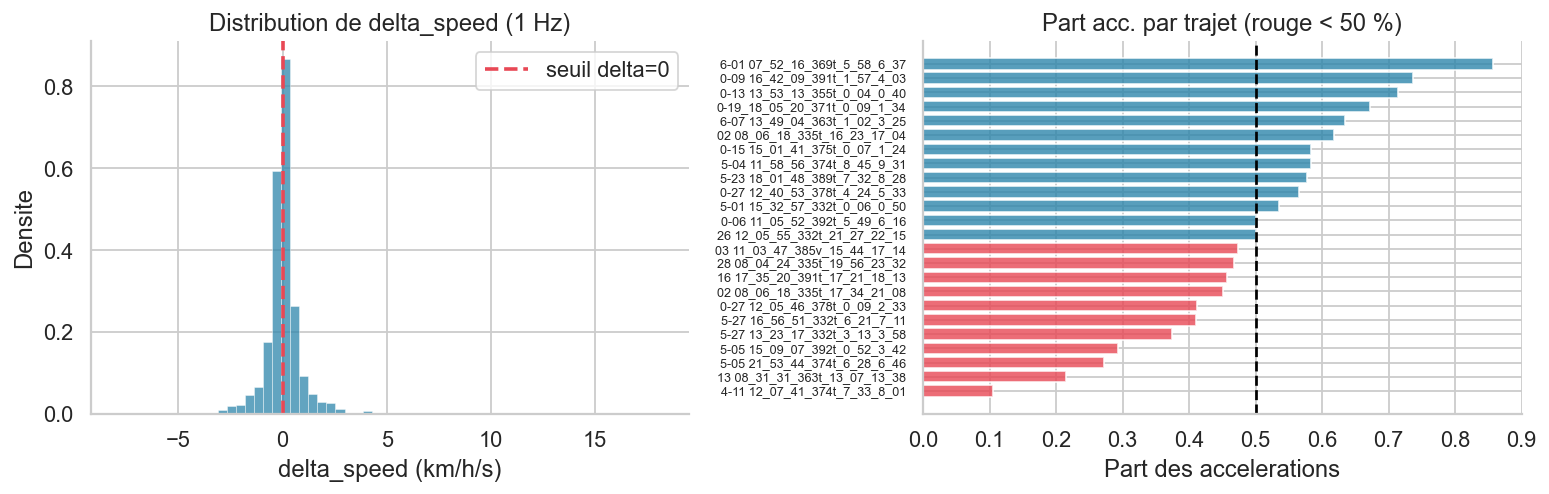

In [33]:
df_1hz['speed_next']  = df_1hz.groupby('source')['speed_kmh'].shift(-1)
df_1hz['delta_speed'] = df_1hz['speed_next'] - df_1hz['speed_kmh']

df_model = df_1hz.dropna(subset=['delta_speed', 'speed_kmh',
                                  'n_pedestrians', 
                                  'road_width_perp_m']).copy()

df_model['choice'] = (df_model['delta_speed'] > 0).astype(int)

n_acc = df_model['choice'].sum()
n_dec = len(df_model) - n_acc
print(f'Observations totales : {len(df_model):,}')
print(f'  Accelerer (1) : {n_acc:,}  ({n_acc/len(df_model)*100:.1f} %)')
print(f'  Decelerer (0) : {n_dec:,}  ({n_dec/len(df_model)*100:.1f} %)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(df_model['delta_speed'], bins=60, color=COLOR_ACC, alpha=0.75,
        edgecolor='white', lw=0.3, density=True)
ax.axvline(0, color=COLOR_DEC, lw=2, ls='--', label='seuil delta=0')
ax.set_xlabel('delta_speed (km/h/s)')
ax.set_ylabel('Densite')
ax.set_title('Distribution de delta_speed (1 Hz)')
ax.legend()

ax = axes[1]
share = df_model.groupby('source')['choice'].mean().sort_values()
colors_bar = [COLOR_DEC if v < 0.5 else COLOR_ACC for v in share.values]
ax.barh(range(len(share)), share.values, color=colors_bar, alpha=0.8)
ax.axvline(0.5, color='black', lw=1.5, ls='--')
ax.set_yticks(range(len(share)))
ax.set_yticklabels([s[-28:] for s in share.index], fontsize=7)
ax.set_xlabel('Part des accelerations')
ax.set_title('Part acc. par trajet (rouge < 50 %)')
plt.tight_layout()
plt.show()


## 5 · Standardisation & création de dummy

**Variables standardisees** (`z = (x - mu) / sigma`) : coefficients comparables.


In [34]:
# ── Variables continues : z-scores ───────────────────────────────────────────
cont_vars = ['speed_kmh', 'n_pedestrians', 'road_width_perp_m', 'hour','prop_vru_pedestrian','prop_vru_cyclist','prop_interaction_same_direction']

cont_vars = [
    v for v in cont_vars
    if v in df_model.columns and df_model[v].notna().any()
]

means_ = df_model[cont_vars].mean()
stds_  = df_model[cont_vars].std()

for v in cont_vars:
    if pd.notna(stds_[v]) and stds_[v] != 0:
        df_model[f'z_{v}'] = (df_model[v] - means_[v]) / stds_[v]
    else:
        df_model[f'z_{v}'] = 0.0
        print(f'  ⚠  {v} a un écart-type nul → z_{v}=0 pour toutes les lignes')

print('Statistiques des z-scores (doivent être ~mean=0, std=1) :')
display(df_model[[f'z_{v}' for v in cont_vars]].describe().round(3))


# ── Variables catégorielles : toutes les non-continues ──────────────────────
# On exclut :
#   - les variables continues brutes
#   - leurs z-scores
#   - la cible éventuelle (à adapter si besoin)
#   - les identifiants / colonnes non souhaitées
#   - source, qu'on garde pour les effets fixes trajets

exclude_from_cat = set(cont_vars)
exclude_from_cat.update([f'z_{v}' for v in cont_vars])
exclude_from_cat.update([
    'source',          # traité séparément comme effet fixe
    # ajoute ici ta/tes variable(s) cible(s) si besoin
    # ex: 'severity', 'y', etc.
])

candidate_cat_vars = [
    c for c in df_model.columns
    if c not in exclude_from_cat
]

# On garde comme catégorielles :
# - colonnes object / category / bool
# - ou colonnes numériques discrètes avec peu de modalités
cat_vars = []

for col in candidate_cat_vars:
    s = df_model[col]

    if s.notna().sum() == 0:
        continue

    if (
        pd.api.types.is_object_dtype(s)
        or pd.api.types.is_categorical_dtype(s)
        or pd.api.types.is_bool_dtype(s)
    ):
        cat_vars.append(col)

    elif pd.api.types.is_numeric_dtype(s):
        # numérique mais discret → on le traite comme catégoriel
        nunique = s.dropna().nunique()
        if nunique <= 10:
            cat_vars.append(col)

print('\nVariables catégorielles détectées automatiquement :')
print(cat_vars)


# ── Dummies catégorielles avec référence = modalité la plus fréquente ───────
categorical_dummy_cols = []
ref_levels = {}

for col in cat_vars:
    s = df_model[col]

    if s.notna().sum() == 0:
        print(f'  ⚠  {col} entièrement vide — ignoré')
        continue

    # modalité de référence = la plus fréquente
    vc = s.value_counts(dropna=True)
    if vc.empty:
        print(f'  ⚠  {col} sans valeur exploitable — ignoré')
        continue

    ref = vc.index[0]
    ref_levels[col] = ref

    uniq = s.dropna().unique().tolist()

    # on force la référence en première position
    remaining = [v for v in uniq if v != ref]
    try:
        remaining = sorted(remaining)
    except Exception:
        remaining = [str(v) for v in remaining]
        ref = str(ref)
        s = s.astype(str).where(s.notna(), np.nan)

    cats = [ref] + remaining

    dummies = pd.get_dummies(
        pd.Categorical(s, categories=cats, ordered=False),
        prefix=col,
        drop_first=True
    )

    dummies = dummies.astype(int)

    df_model = pd.concat(
        [df_model.reset_index(drop=True), dummies.reset_index(drop=True)],
        axis=1
    )

    categorical_dummy_cols.extend(dummies.columns.tolist())

    print(
        f'  {col:20s} → {len(dummies.columns)} dummies  '
        f'(réf = {ref!r}, n={vc.iloc[0]})  |  {dummies.columns.tolist()}'
    )

print(f'\nDummies catégorielles ajoutés : {len(categorical_dummy_cols)}')
print(f'Colonnes : {categorical_dummy_cols}')



# ── Récapitulatif des blocs de variables ─────────────────────────────────────
print('\n' + '=' * 55)
print('Récapitulatif des blocs de variables')
print('=' * 55)
print(f'  Variables continues : {cont_vars}')
print(f'  Z-scores continus   : {[f"z_{v}" for v in cont_vars]}')
print(f'  Variables cat.      : {cat_vars}')
print(f'  Références choisies : {ref_levels}')
print(f'  Dummies catégorielles : {categorical_dummy_cols}')
print(f'\n  Total colonnes model: {df_model.shape[1]}')
print(f'  Total lignes        : {df_model.shape[0]}')

Statistiques des z-scores (doivent être ~mean=0, std=1) :


,z_speed_kmh,z_n_pedestrians,z_road_width_perp_m,z_hour,z_prop_vru_pedestrian,z_prop_vru_cyclist,z_prop_interaction_same_direction
count,1174.000,1174.000,1174.000,1174.000,1174.000,1174.000,1174.000
mean,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.714,-1.246,-1.222,-1.550,-2.959,-0.382,-1.155
25%,-0.758,-0.894,-0.618,-1.268,0.382,-0.382,-1.155
50%,-0.364,-0.190,-0.416,-0.141,0.382,-0.382,0.083
75%,0.805,0.513,0.419,0.704,0.382,-0.382,1.321
max,2.475,4.031,6.239,2.675,0.382,2.959,1.321



Variables catégorielles détectées automatiquement :
['day_of_week', 'day_name', 'is_weekend', 'time_of_day', 'month', 'season', 'genre', 'experience', 'choice']
  day_of_week          → 6 dummies  (réf = np.int64(4), n=418)  |  ['day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_5', 'day_of_week_6']
  day_name             → 6 dummies  (réf = 'Friday', n=418)  |  ['day_name_Monday', 'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday', 'day_name_Tuesday', 'day_name_Wednesday']
  is_weekend           → 1 dummies  (réf = np.False_, n=1018)  |  ['is_weekend_True']
  time_of_day          → 3 dummies  (réf = 'Morning', n=728)  |  ['time_of_day_Afternoon', 'time_of_day_Evening', 'time_of_day_Night']
  month                → 3 dummies  (réf = np.int64(10), n=402)  |  ['month_4', 'month_5', 'month_6']
  season               → 2 dummies  (réf = 'Spring', n=466)  |  ['season_Autumn', 'season_Summer']
  genre                → 1 dummies  (réf = 'male', n=603)  

# Betas and variables

In [35]:
import re

def normalize(name: str) -> str:
    clean = name.lower()
    clean = re.sub(r'[^a-z0-9]+', '_', clean)
    clean = re.sub(r'_+', '_', clean)
    clean = clean.strip('_')
    if re.match(r'^[0-9]', clean):
        clean = "var_" + clean
    return clean

# dummies + continues standardisées
continuous_model_cols = [f"z_{v}" for v in cont_vars if f"z_{v}" in df_model.columns]
model_cols = categorical_dummy_cols.copy() + continuous_model_cols

print("Variables catégorielles :", categorical_dummy_cols)
print("Variables continues     :", continuous_model_cols)
print("Total variables modèle  :", len(model_cols))

created_variables = []
created_betas = []

for col in model_cols:
    clean_name = normalize(col)

    if clean_name == "":
        print(f"Skip (empty after cleaning): {col}")
        continue

    if not clean_name.isidentifier():
        print(f"Skip (invalid identifier): {clean_name} ← {col}")
        continue

    # Crée la Variable Biogeme directement dans le namespace global
    if clean_name not in globals():
        globals()[clean_name] = Variable(col)
        created_variables.append(clean_name)

    # Crée le Beta associé directement dans le namespace global
    beta_name = f"beta_{clean_name}_acc"

    if not beta_name.isidentifier():
        print(f"Skip beta (invalid identifier): {beta_name}")
        continue

    if beta_name not in globals():
        globals()[beta_name] = Beta(beta_name, 0, None, None, 0)
        created_betas.append(beta_name)

print(f"\n✔ Variables Biogeme créées : {len(created_variables)}")
print(created_variables)

print(f"\n✔ Betas créés : {len(created_betas)}")
print(created_betas)

Variables catégorielles : ['day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_5', 'day_of_week_6', 'day_name_Monday', 'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday', 'day_name_Tuesday', 'day_name_Wednesday', 'is_weekend_True', 'time_of_day_Afternoon', 'time_of_day_Evening', 'time_of_day_Night', 'month_4', 'month_5', 'month_6', 'season_Autumn', 'season_Summer', 'genre_female', 'experience_0.5-1', 'experience_1-2', 'experience_<0.5', 'choice_1']
Variables continues     : ['z_speed_kmh', 'z_n_pedestrians', 'z_road_width_perp_m', 'z_hour', 'z_prop_vru_pedestrian', 'z_prop_vru_cyclist', 'z_prop_interaction_same_direction']
Total variables modèle  : 33

✔ Variables Biogeme créées : 3
['z_prop_vru_pedestrian', 'z_prop_vru_cyclist', 'z_prop_interaction_same_direction']

✔ Betas créés : 3
['beta_z_prop_vru_pedestrian_acc', 'beta_z_prop_vru_cyclist_acc', 'beta_z_prop_interaction_same_direction_acc']


In [39]:
# ── Dictionnaire de correspondance Beta → LaTeX ─────────────────────────────
# À définir UNE FOIS en haut du notebook, à compléter au fur et à mesure
import re

def _var_to_latex(var_name):
    var_name = str(var_name).strip()
    return rf'x_{{\text{{{var_name.replace("_", " ")}}}}}'

BETA_LABELS = {
    'ASC': r'\text{ASC}',
    'beta_time_of_day_afternoon_acc': r'\beta_{\text{Afternoon}}',
    'beta_genre_female_acc': r'\beta_{\text{Genre Female}}',
    'beta_z_n_pedestrians_acc': r'\beta_{\text{Number of Pedestrians}}',
}
def _df_to_latex_params(df, model_name):
    """Génère un tableau LaTeX des paramètres estimés."""

    col_value   = next(c for c in df.columns if 'value'   in c.lower())
    col_stderr  = next(c for c in df.columns if 'std'     in c.lower())
    col_tstat   = next(c for c in df.columns if 't-stat'  in c.lower() or 'tstat' in c.lower())
    col_pvalue  = next(c for c in df.columns if 'p-value' in c.lower() or 'pvalue' in c.lower())

    # colonne contenant le nom du paramètre, si elle existe
    possible_name_cols = ['Name', 'name', 'Parameter', 'parameter', 'Beta', 'beta']
    col_param = next((c for c in possible_name_cols if c in df.columns), None)

    lines = [
        r'\begin{table}[h!]\centering\small',
        r'\begin{tabular}{lrrrr}',
        r'\hline\hline',
        r'Paramètre & Valeur & Std. err. rob. & $t$-stat. rob. & $p$-valeur \\',
        r'\hline',
    ]

    unmatched = []

    for idx, row in df.iterrows():
        # si index numérique, on prend la colonne paramètre
        if col_param is not None:
            beta_name = str(row[col_param]).strip()
        else:
            beta_name = str(idx).strip()

        if beta_name in BETA_LABELS:
            label = f'${BETA_LABELS[beta_name]}$'
        else:
            clean = beta_name.replace('beta_', '').replace('_acc', '').replace('_', ' ')
            label = rf'$\beta_{{\text{{{clean}}}}}$'
            unmatched.append(beta_name)

        sig = (r' $^{***}$' if row[col_pvalue] < .001 else
               r' $^{**}$'  if row[col_pvalue] < .01  else
               r' $^{*}$'   if row[col_pvalue] < .05  else '')

        lines.append(
            f'{label} & {row[col_value]:.4f} & {row[col_stderr]:.4f}'
            f' & {row[col_tstat]:.3f} & {row[col_pvalue]:.4f}{sig} \\\\'
        )

    lines += [
        r'\hline\hline',
        r'\end{tabular}',
        rf'\caption{{Estimated parameters of the logit model predicting the speed change}}',
        rf'\label{{tab:{model_name}_params}}',
        r'\end{table}',
    ]

    if unmatched:
        print("\nBetas sans mapping explicite dans BETA_LABELS :")
        for b in sorted(set(unmatched)):
            print("  ", repr(b))

    return '\n'.join(lines)
def _metrics_to_latex(metrics, metrics_const, lrt_stat, lrt_df, lrt_p, model_name):
    """Génère un tableau LaTeX des statistiques générales du modèle."""
    sig = (r'$^{***}$' if lrt_p < .001 else r'$^{**}$' if lrt_p < .01
           else r'$^{*}$' if lrt_p < .05 else '')
    rows = [
        (r'$N$',                                    f'{metrics["N"]}'),
        (r'$K$',                                    f'{metrics["K"]}'),
        (r'$\mathcal{L}(\text{cst})$',              f'{metrics_const["LL_final"]:.2f}'),
        (r'$\mathcal{L}(\hat{\beta})$',             f'{metrics["LL_final"]:.2f}'),
        (r'$\rho^2$',                               f'{metrics["rho2"]:.4f}'),
        (r'$\bar{\rho}^2$',                         f'{metrics["rho2_bar"]:.4f}'),
        (r'AIC',                                    f'{metrics["AIC"]:.2f}'),
        (r'BIC',                                    f'{metrics["BIC"]:.2f}'),
        (rf'LRT $\chi^2({lrt_df})$ vs cst',        f'{lrt_stat:.2f}{sig}'),
        (r'$p$-valeur LRT',                         f'{lrt_p:.4f}'),
    ]
    lines = [
        r'\begin{table}[h!]\centering\small',
        r'\begin{tabular}{lr}',
        r'\hline\hline',
        r'Statistique & Valeur \\',
        r'\hline',
    ] + [rf'{label} & {val} \\' for label, val in rows] + [
        r'\hline\hline',
        r'\end{tabular}',
        rf'\caption{{Statistics of the logit model predicting the speed change}}',
        rf'\label{{tab:{model_name}_stats}}',
        r'\end{table}',
    ]
    return '\n'.join(lines)

## 6 · Fonction utilitaire Biogeme

Encapsule l'estimation d'un **logit binaire** :
- Utilite alternative 1 (accelerer) : `V1 = ASC + sum(beta_k * x_k)`
- Utilite alternative 0 (decelerer) : `V0 = 0` (reference)
- Retourne : resultats Biogeme, tableau de coefficients, metriques (rho2, AIC, BIC)


In [40]:
import os, shutil
import numpy as np
import biogeme.biogeme as bio
import biogeme.database as db
import biogeme.expressions as ex
import biogeme.models as models
import biogeme.results as rp
from biogeme.parameters import Parameters


def _get_out_dir(model_name):
    base = os.path.join('model_results', model_name)
    if not os.path.exists(base):
        return base
    i = 2
    while os.path.exists(f'{base}_v{i}'):
        i += 1
    return f'{base}_v{i}'



def _extract_vars(utility_expr):
    """Retourne les noms de colonnes-données (Variable) dans l'expression."""
    vars_ = []
    if isinstance(utility_expr, ex.Variable):
        vars_.append(utility_expr.name)
    for child in getattr(utility_expr, 'children', []):
        vars_.extend(_extract_vars(child))
    return list(dict.fromkeys(vars_))


def _extract_betas(expr):
    """Retourne tous les nœuds Beta dans l'expression (récursif)."""
    betas = []
    if isinstance(expr, ex.Beta):
        betas.append(expr)
    for child in getattr(expr, 'children', []):
        betas.extend(_extract_betas(child))
    return betas


def _run_biogeme(database, logprob, model_name, params_bio):
    m = bio.BIOGEME(database, logprob, parameters=params_bio)
    m.model_name = model_name
    m.calculate_null_loglikelihood({1: ex.Numeric(1), 0: ex.Numeric(1)})
    res = m.estimate()
    return m, res   # ← tuple (m, res)
def run_logit(df_est, utility, model_name, asc=None):

    # ── 1. Données ─────────────────────────────────────────────────────────
    utility_vars = _extract_vars(utility)
    cols = ['choice'] + utility_vars
    before = len(df_est)
    data = df_est[cols].dropna().copy()
    dropped = before - len(data)
    if dropped:
        print(f'[{model_name}] ⚠ {dropped} lignes supprimées (NaN)')
    # après
    for col in data.columns:
        if pd.api.types.is_bool_dtype(data[col]):
            data[col] = data[col].astype(int)
    N = len(data)
    database = db.Database(model_name, data)

    # ── 2. Paramètres Biogeme ──────────────────────────────────────────────
    params_bio = Parameters()
    params_bio.set_value('generate_html',   True)
    params_bio.set_value('generate_yaml',   False)
    params_bio.set_value('generate_netcdf', False)
    V0 = ex.Numeric(0)

    # ── 3. Modèle constant (ASC seul) ──────────────────────────────────────
    const_name = f'{model_name}_constant'
    if asc is None:
        all_betas = _extract_betas(utility)
        asc_betas = [b for b in all_betas if b.name.lower().startswith('asc')]
        asc = asc_betas[0] if asc_betas else ex.Beta('ASC', 0, None, None, 0)

    logprob_const = models.loglogit({1: asc, 0: V0}, None, ex.Variable('choice'))
    db_const      = db.Database(const_name, data)
    _, res_const  = _run_biogeme(db_const, logprob_const, const_name, params_bio)

    ll_const = res_const.raw_estimation_results.final_log_likelihood
    k_const  = 1

    ll_null  = res_const.raw_estimation_results.null_log_likelihood

    # ── 4. Modèle principal ─────────────────────────────────────────────────
    logprob    = models.loglogit({1: utility, 0: V0}, None, ex.Variable('choice'))
    m_main, res = _run_biogeme(database, logprob, model_name, params_bio)

    # ── 5. Métriques ────────────────────────────────────────────────────────
    final_ll = res.raw_estimation_results.final_log_likelihood
    k        = len(res.get_beta_values())

    def _metrics(ll_f, ll_0, n, nk, name):
        rho2     = 1 - ll_f / ll_0         if ll_0 != 0 else float('nan')
        rho2_bar = 1 - (ll_f - nk) / ll_0 if ll_0 != 0 else float('nan')
        aic      = -2 * ll_f + 2 * nk
        bic      = -2 * ll_f + nk * np.log(n)
        return dict(Model=name, N=n, K=nk,
                     LL_final=round(ll_f, 2),
                    rho2=round(rho2, 4),     rho2_bar=round(rho2_bar, 4),
                    AIC=round(aic, 2),       BIC=round(bic, 2))

    metrics_const = _metrics(ll_const, ll_null, N, k_const, const_name)
    metrics       = _metrics(final_ll, ll_null, N, k,       model_name)

    from scipy import stats as sp_stats
    lrt_stat = -2 * (ll_const - final_ll)
    lrt_df   = k - k_const
    lrt_p    = sp_stats.chi2.sf(lrt_stat, lrt_df)

    metrics['LRT_stat'] = round(lrt_stat, 2)
    metrics['LRT_df']   = lrt_df
    metrics['LRT_p']    = round(lrt_p, 4)

    # ── 6. params_df ────────────────────────────────────────────────────────
    params_df = res.get_estimated_parameters()
    params_df.columns = [c.strip() for c in params_df.columns]

    # ── 7. Sauvegarde (après params_df et metrics) ──────────────────────────
    out_dir = _get_out_dir(model_name)
    os.makedirs(out_dir)
    with open(os.path.join(out_dir, f'{model_name}_params.tex'), 'w') as f:
        f.write(_df_to_latex_params(params_df, model_name))
    with open(os.path.join(out_dir, f'{model_name}_stats.tex'), 'w') as f:
        f.write(_metrics_to_latex(metrics, metrics_const,
                                   lrt_stat, lrt_df, lrt_p, model_name))

    # Déplacement des fichiers générés par Biogeme vers out_dir
    # Biogeme génère parfois les fichiers avec un préfixe '__'
    for name in [model_name, const_name]:
        for prefix in ['', '__']:
            for ext in ['.iter', '.html']:
                fname = f'{prefix}{name}{ext}'
                if os.path.exists(fname):
                    shutil.move(fname, os.path.join(out_dir, fname))

    # Déplacement des fichiers générés par Biogeme vers out_dir
    for fname in [
        f'{model_name}.iter',
        f'{model_name}.html',
        f'{const_name}.iter',
        f'{const_name}.html',
    ]:
        if os.path.exists(fname):
            shutil.move(fname, os.path.join(out_dir, fname))
    # ── 8. Affichage ────────────────────────xz────────────────────────────────
    print(f'\n{"="*65}')
    print(f'  Modèle constant  ({const_name})')
    print(f'  LL={ll_const:.2f}  rho2={metrics_const["rho2"]:.4f}'
          f'  AIC={metrics_const["AIC"]:.1f}')
    print(f'{"─"*65}')
    print(f'  Modèle principal ({model_name})')
    print(f'  N={N}  K={k}  LL={final_ll:.2f}  rho2={metrics["rho2"]:.4f}'
          f'  AIC={metrics["AIC"]:.1f}')
    print(f'{"─"*65}')
    sig = (' ***' if lrt_p < .001 else ' **' if lrt_p < .01
           else ' *'   if lrt_p < .05  else ' (n.s.)')
    print(f'  LRT vs constant : χ²({lrt_df})={lrt_stat:.2f}  p={lrt_p:.4f}{sig}')
    print(f'{"="*65}')

    display(params_df.style.format({
        'Value':           '{:.4f}',
        'Robust std err.': '{:.4f}',
        'Robust t-stat.':  '{:.3f}',
        'Robust p-value':  '{:.4f}',
    }))

    return res, params_df, metrics, metrics_const

## 7 · Modele 0 — Constante seule (null model)

Seul l'ASC capture la propension marginale a accelerer. Sert de reference pour rho2.

In [41]:
all_metrics = []
all_params  = {}
all_res     = {}

# ── M0 : modèle nul (ASC seul) ─────────────────────────────────────────────
# Pas besoin d'appeler run_logit ici — le modèle constant est estimé
# automatiquement en interne à chaque appel. On peut quand même le stocker
# si on veut ses métriques dans le tableau comparatif.

ASC = ex.Beta('ASC', 0, None, None, 0)

res0, p0, m0, m0_const = run_logit(df_model, ASC, 'M0_null')
all_metrics.append(m0_const)   # modèle constant (ASC seul) = notre M0
all_metrics.append(m0)         # modèle M0_null (idem ici, redondant mais cohérent)
all_params['M0_null'] = p0
all_res['M0_null']    = res0



  Modèle constant  (M0_null_constant)
  LL=-813.67  rho2=0.0001  AIC=1629.3
─────────────────────────────────────────────────────────────────
  Modèle principal (M0_null)
  N=1174  K=1  LL=-813.67  rho2=0.0001  AIC=1629.3
─────────────────────────────────────────────────────────────────
  LRT vs constant : χ²(0)=-0.00  p=nan (n.s.)


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,ASC,-0.0239,0.0584,-0.409,0.6829


## 8 · Modele 1 — Pietons + Distance

Variables :
- `z_n_pedestrians` : nombre de pietons a moins de 15 m (z-score)
- `z_distance_smooth_m` : distance au pieton le plus proche (z-score)

In [42]:
# ── M1 : piétons + distance ─────────────────────────────────────────────────
ASC       = ex.Beta('ASC',            0, None, None, 0)

utility_M2 = (
    ASC
    + beta_z_n_pedestrians_acc* z_n_pedestrians
)

res2, p2, m2, _ = run_logit(df_model, utility_M2, 'M2_ped_dist')
all_metrics.append(m2)
all_params['M2_ped_dist'] = p2
all_res['M2_ped_dist']    = res2


  Modèle constant  (M2_ped_dist_constant)
  LL=-813.67  rho2=0.0001  AIC=1629.3
─────────────────────────────────────────────────────────────────
  Modèle principal (M2_ped_dist)
  N=1174  K=2  LL=-811.85  rho2=0.0023  AIC=1627.7
─────────────────────────────────────────────────────────────────
  LRT vs constant : χ²(1)=3.64  p=0.0565 (n.s.)


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,ASC,-0.0240,0.0585,-0.411,0.6810
1,beta_z_n_pedestrians_acc,-0.1117,0.0596,-1.875,0.0608


## 9 · Modele 2 — + Largeur de route

Ajoute : `z_road_width_perp_m` (largeur perpendiculaire de la voirie, z-score)

In [44]:
# ── M1 : piétons + distance ─────────────────────────────────────────────────
ASC       = ex.Beta('ASC',            0, None, None, 0)

utility_M3 = (ASC
              + beta_z_prop_vru_pedestrian_acc* z_prop_vru_pedestrian + beta_z_n_pedestrians_acc*z_n_pedestrians
              + beta_z_prop_interaction_same_direction_acc
              #+ beta_genre_female_acc * genre_female
              )

res3, p3, m3, _ = run_logit(df_model, utility_M3, 'M3_ped_dist')
all_metrics.append(m3)
all_params['M2_ped_dist'] = p3
all_res['M2_ped_dist']    = res3


Betas sans mapping explicite dans BETA_LABELS :
   'beta_z_prop_interaction_same_direction_acc'
   'beta_z_prop_vru_pedestrian_acc'

  Modèle constant  (M3_ped_dist_constant)
  LL=-813.67  rho2=0.0001  AIC=1629.3
─────────────────────────────────────────────────────────────────
  Modèle principal (M3_ped_dist)
  N=1174  K=4  LL=-809.42  rho2=0.0053  AIC=1626.8
─────────────────────────────────────────────────────────────────
  LRT vs constant : χ²(3)=8.50  p=0.0368 *


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,ASC,-0.0237,0.0293,-0.808,0.4189
1,beta_z_prop_vru_pedestrian_acc,-0.1430,0.0652,-2.192,0.0284
2,beta_z_n_pedestrians_acc,-0.0531,0.0650,-0.818,0.4134
3,beta_z_prop_interaction_same_direction_acc,0.0005,0.0293,0.018,0.9860


In [45]:
# ── M1 : piétons + distance ─────────────────────────────────────────────────
ASC       = ex.Beta('ASC',            0, None, None, 0)

utility_M3 = (ASC
              + beta_pro
              + beta_genre_female_acc * genre_female)

res3, p3, m3, _ = run_logit(df_model, utility_M3, 'M3_ped_dist')
all_metrics.append(m3)
all_params['M2_ped_dist'] = p3
all_res['M2_ped_dist']    = res3

NameError: name 'beta_pro' is not defined

## 11 · Comparaison des modeles

**LR-test** : pour deux modeles emboites, `LR = -2*(LL_r - LL_f) ~ chi2(Delta_K)`.

In [ ]:
comparison = pd.DataFrame(all_metrics).set_index('Model')
display(comparison.style
    .background_gradient(subset=['rho2','rho2_bar'], cmap='Greens')
    .background_gradient(subset=['AIC','BIC'],        cmap='Reds_r')
    .format({'LL_null':'{:.1f}','LL_final':'{:.1f}',
             'rho2':'{:.4f}','rho2_bar':'{:.4f}',
             'AIC':'{:.1f}','BIC':'{:.1f}'}))

def lr_test(r_res, f_res, delta_k):
    lr = -2 * (r_res.raw_estimation_results.final_log_likelihood
               - f_res.raw_estimation_results.final_log_likelihood)
    return lr, stats.chi2.sf(lr, delta_k)

lr01, p01 = lr_test(res0, res1, m1['K'] - m0['K'])
lr12, p12 = lr_test(res1, res2, m2['K'] - m1['K'])
lr23, p23 = lr_test(res2, res3, m3['K'] - m2['K'])

print('\nLR-tests (modeles emboites) :')
print(f'  M0 -> M1 : LR={lr01:.2f}  Delta_df={m1["K"]-m0["K"]}  p={p01:.4e}')
print(f'  M1 -> M2 : LR={lr12:.2f}  Delta_df={m2["K"]-m1["K"]}  p={p12:.4e}')
print(f'  M2 -> M3 : LR={lr23:.2f}  Delta_df={m3["K"]-m2["K"]}  p={p23:.4e}')


## 12 · Visualisation comparaison des modeles

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
mnames = comparison.index.tolist()
x = np.arange(len(mnames))

ax = axes[0]
ax.bar(x, comparison['rho2'],     width=0.5, color=COLOR_ACC, alpha=0.85, label='rho2')
ax.bar(x, comparison['rho2_bar'], width=0.5, color='#5BC0EB', alpha=0.45, label='rho2_bar')
ax.set_xticks(x); ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('McFadden rho2'); ax.set_ylabel('rho2'); ax.legend(fontsize=8)
ax.axhline(0.2, ls='--', lw=1, color='gray', alpha=0.5, label='seuil 0.2')
ax.axhline(0.4, ls=':',  lw=1, color='gray', alpha=0.5, label='seuil 0.4')

ax = axes[1]
ax.bar(x, comparison['AIC'], width=0.5, color=COLOR_DEC, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('AIC  (bas = meilleur)'); ax.set_ylabel('AIC')

ax = axes[2]
ax.bar(x, comparison['BIC'], width=0.5, color='#F4A261', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('BIC  (bas = meilleur)'); ax.set_ylabel('BIC')

plt.suptitle('Comparaison des modeles Biogeme', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 13 · Forest plot des coefficients — M2 & M3

Chaque barre = coefficient estime +/- IC 95 % robuste.
Bleu = effet positif (favorise acceleration), Rouge = effet negatif.

In [ ]:
def forest_plot(ax, params_df, title, fontsize=9):
    coefs  = params_df['Value'].values.astype(float)
    ci95   = (1.96 * params_df['Robust std err.'].values.astype(float))
    pvals  = params_df['Robust p-value'].values.astype(float)
    names  = params_df['Name'].tolist()
    colors = [COLOR_ACC if c >= 0 else COLOR_DEC for c in coefs]
    y_pos  = range(len(names))

    ax.barh(list(y_pos), coefs, xerr=ci95, color=colors,
            alpha=0.75, capsize=3, error_kw={'lw': 1.1})
    ax.axvline(0, color='black', lw=1.2, ls='--')

    for i, p in enumerate(pvals):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if stars:
            offset = 0.02 + ci95[i]
            ax.text(coefs[i] + np.sign(coefs[i]) * offset, i, stars,
                    va='center', fontsize=8, color='black')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(names, fontsize=fontsize)
    ax.set_xlabel('Coefficient (IC 95 %)')
    ax.set_title(title)

# M2 — variables substantielles seulement
p2_df = all_params['M2_ped_dist_width'].copy()

# M3 — separer substantielles vs effets fixes
p3_df  = all_params['M3_full'].copy()
p3_main = p3_df[~p3_df['Name'].str.startswith('b_traj')].copy()
p3_fe   = p3_df[p3_df['Name'].str.startswith('b_traj')].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, max(5, len(p3_fe)*0.4 + 3)))

forest_plot(axes[0], p2_df,    'M2 — Variables substantielles')
forest_plot(axes[1], p3_main,  'M3 — Variables substantielles')
forest_plot(axes[2], p3_fe,    'M3 — Effets fixes trajets',
            fontsize=max(6, 9 - len(p3_fe)//6))

axes[2].set_yticklabels(
    [n.replace('b_traj_', '')[-22:] for n in p3_fe['Name']],
    fontsize=max(6, 9 - len(p3_fe)//6))

plt.suptitle('Forest plot  (* p<.05  ** p<.01  *** p<.001)', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 14 · Effets marginaux (M2)

Formule du logit : `dP/dx_k = beta_k * P(acc) * (1 - P(acc))`

Evalues a la **moyenne** (z-scores = 0).
Les effets sont convertis en **unites originales** divisant par l'ecart-type.

In [ ]:
p2_betas = dict(zip(all_params['M2_ped_dist_width']['Name'],
                    all_params['M2_ped_dist_width']['Value'].astype(float)))

asc_val = p2_betas.get('ASC', 0.0)
P_mean  = 1 / (1 + np.exp(-asc_val))
print(f'P(accelerer) evaluee a la moyenne des variables : {P_mean:.4f}')

var_map = {
    'b_z_n_pedestrians':     ('n_pedestrians',     stds_['n_pedestrians']),
    'b_z_distance_smooth_m': ('distance_smooth_m', stds_['distance_smooth_m']),
    'b_z_road_width_perp_m': ('road_width_perp_m', stds_['road_width_perp_m']),
}

me_rows = []
for bname, (raw_name, sd) in var_map.items():
    beta_z = p2_betas.get(bname, float('nan'))
    me     = (beta_z / sd) * P_mean * (1 - P_mean)
    me_rows.append({'Variable': raw_name,
                    'beta_z':   round(beta_z, 4),
                    'ME (unite originale)': round(me, 6)})

me_df = pd.DataFrame(me_rows)
display(me_df)

fig, ax = plt.subplots(figsize=(8, 3))
colors_me = [COLOR_ACC if v >= 0 else COLOR_DEC
             for v in me_df['ME (unite originale)']]
ax.barh(me_df['Variable'], me_df['ME (unite originale)'],
        color=colors_me, alpha=0.8)
ax.axvline(0, color='black', lw=1.2, ls='--')
ax.set_xlabel('dP(accelerer) / dx  (unite originale)')
ax.set_title('Effets marginaux — M2 (evalues a la moyenne)')
plt.tight_layout(); plt.show()


## 15 · Courbes de probabilite predite (M2)

Chaque graphique fait varier **une variable** sur son etendue (p2-p98),
toutes les autres maintenues a leur moyenne (z=0).

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vars_plot = [
    ('z_n_pedestrians',     'n_pedestrians',     'Nb pietons'),
    ('z_distance_smooth_m', 'distance_smooth_m', 'Distance (m)'),
    ('z_road_width_perp_m', 'road_width_perp_m', 'Largeur route (m)'),
]

for ax, (z_var, raw_var, label) in zip(axes, vars_plot):
    x_raw = np.linspace(df_model[raw_var].quantile(0.02),
                        df_model[raw_var].quantile(0.98), 200)
    x_z   = (x_raw - means_[raw_var]) / stds_[raw_var]

    beta_foc = p2_betas.get(f'b_{z_var}', 0.0)
    V1_grid  = asc_val + beta_foc * x_z
    P_grid   = 1 / (1 + np.exp(-V1_grid))

    rng    = np.random.default_rng(42)
    jitter = rng.uniform(-0.025, 0.025, len(df_model))
    ax.scatter(df_model[raw_var], df_model['choice'] + jitter,
               alpha=0.07, s=6, color=COLOR_ACC)
    ax.plot(x_raw, P_grid, color=COLOR_DEC, lw=2.5)
    ax.axhline(0.5, color='gray', lw=1, ls=':', alpha=0.8)
    ax.set_ylim(-0.12, 1.12)
    ax.set_xlabel(label)
    ax.set_ylabel('P(accelerer)')
    ax.set_title(f'P(acc) ~ {label}')

plt.suptitle(
    'Probabilite d acceleration — courbes predites M2\n'
    '(autres variables a leur moyenne)',
    fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## 16 · Heatmap de probabilite predite — pietons x distance (M2)

In [ ]:
ped_vals  = np.array([1, 2, 3, 4, 5])
dist_vals = np.linspace(df_model['distance_smooth_m'].quantile(0.05),
                         df_model['distance_smooth_m'].quantile(0.95), 8)

grid_ped, grid_dist = np.meshgrid(ped_vals, dist_vals)

z_ped  = (grid_ped  - means_['n_pedestrians'])     / stds_['n_pedestrians']
z_dist = (grid_dist - means_['distance_smooth_m'])  / stds_['distance_smooth_m']

b_ped  = p2_betas.get('b_z_n_pedestrians',     0.0)
b_dist = p2_betas.get('b_z_distance_smooth_m', 0.0)

V1_grid = asc_val + b_ped * z_ped + b_dist * z_dist
P_grid  = 1 / (1 + np.exp(-V1_grid))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(P_grid, aspect='auto', origin='lower',
               cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='P(accelerer)')

ax.set_xticks(range(len(ped_vals)))
ax.set_xticklabels(ped_vals)
ax.set_yticks(range(len(dist_vals)))
ax.set_yticklabels([f'{v:.1f}' for v in dist_vals])
ax.set_xlabel('Nb pietons (<15 m)')
ax.set_ylabel('Distance au pieton le plus proche (m)')
ax.set_title('P(accelerer) predite par M2\n(largeur route = moyenne)')

for i in range(len(dist_vals)):
    for j in range(len(ped_vals)):
        ax.text(j, i, f'{P_grid[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black')

plt.tight_layout(); plt.show()


## 17 · Synthese & prochaines etapes

### Lecture des coefficients (logit, z-scores standardises)

| Signe beta | Interpretation |
|------------|----------------|
| beta > 0 | la variable **augmente** P(accelerer) |
| beta < 0 | la variable **reduit** P(accelerer) |

Les coefficients sont comparables entre eux (z-scores).

### Reperes pour rho2 McFadden

| rho2 | Qualite |
|------|--------|
| 0.10 – 0.20 | Acceptable |
| 0.20 – 0.40 | Bon |
| > 0.40 | Excellent |

### Pistes d extension

1. **Interaction** `z_distance x z_n_pedestrians` : la distance a-t-elle un effet different selon la densite ?
2. **Vitesse courante** `z_speed_kmh` comme covariable de controle (la vitesse initiale contraint la marge d acceleration)
3. **Mixed logit** (parametre aleatoire sur `n_pedestrians`) pour capturer l heterogeneite individuelle de la reaction
4. **Validation** : split train/test par trajet, courbe ROC, AUC
5. **Ordered logit** si on distingue fort freinage / maintien / forte acceleration (3 classes)
